In [1]:
import re
from pathlib import Path

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

In [2]:
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"
JOB_DESC_DIR = DATA_DIR / "job_descriptions"
SAMPLE_RESUME_DIR = DATA_DIR / "sample_resume"

print("Data directory:", DATA_DIR)
print("Job description directory:", JOB_DESC_DIR)
print("Sample resume directory:", SAMPLE_RESUME_DIR)

Data directory: ..\data
Job description directory: ..\data\job_descriptions
Sample resume directory: ..\data\sample_resume


In [3]:
resume_path = DATA_DIR / "sample_resume.txt"

resume_text = resume_path.read_text(encoding="utf-8")

print("Resume length:", len(resume_text))
print(resume_text[:1000])

Resume length: 2110
Rafhiromadoni Sopandi is an Informatics graduate with a specialization in Data Science and Intelligent Systems. She has strong interest in data analytics, business intelligence, machine learning, artificial intelligence, dashboard development, and data-driven decision-making.

She has experience as a Data Analyst Intern at BPH Migas, where she worked on data cleaning, data transformation, data integration, exploratory data analysis, and interactive dashboard development using Tableau. She created dashboards to monitor business metrics, registration status, operational indicators, and reporting performance. She also transformed raw data into clear visual reports and actionable insights for stakeholders.

Her technical skills include Python, SQL, Pandas, NumPy, Scikit-learn, TensorFlow, Tableau, Power BI, Microsoft Excel, data visualization, dashboard development, exploratory data analysis, ETL, machine learning, classification, regression, forecasting, clustering, st

In [4]:
def normalize_pdf_spacing(text: str) -> str:
    """
    General normalization for text extracted from PDF.
    This joins separated single-letter tokens without hardcoding specific keywords.
    """
    text = re.sub(r"([A-Za-z])\s+([A-Za-z]{2,})", r"\1\2", text)
    text = re.sub(r"([A-Za-z])\s+([A-Za-z]{2,})", r"\1\2", text)
    return text


def clean_text(text: str) -> str:
    text = str(text)

    # Fix hyphenated line breaks
    text = re.sub(r"(\w)-\s*\n\s*(\w)", r"\1 \2", text)

    # Replace line breaks and tabs
    text = re.sub(r"[\r\n\t]+", " ", text)

    # Normalize PDF spacing
    text = normalize_pdf_spacing(text)

    # Lowercase
    text = text.lower()

    # Keep useful symbols for tech terms
    text = re.sub(r"[^a-z0-9+#.\s/-]", " ", text)

    # Normalize separators
    text = re.sub(r"[/|,;:]+", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [5]:
resume_clean = clean_text(resume_text)

print("Cleaned resume length:", len(resume_clean))
print(resume_clean[:1000])

Cleaned resume length: 1886
rafhiromadonisopandiisan informaticsgraduatewith aspecializationindata scienceandintelligentsystems. shehasstronginterest indataanalytics businessintelligence machinelearning artificialintelligence dashboarddevelopment anddata-drivendecision-making. shehasexperienceas adataanalystintern atbphmigas wheresheworkedon datacleaning datatransformation dataintegration exploratorydataanalysis andinteractivedashboarddevelopment usingtableau. shecreateddashboardsto monitorbusinessmetrics registrationstatus operationalindicators andreportingperformance. shealsotransformedraw dataintoclearvisual reportsandactionableinsights forstakeholders. hertechnicalskillsinclude python sql pandas numpy scikit-learn tensorflow tableau powerbi microsoftexcel datavisualization dashboarddevelopment exploratorydataanalysis etl machinelearning classification regression forecasting clustering statisticalanalysis featureengineering modelevaluation andbusinessintelligence. shehasdevelopedsev

In [6]:
def parse_job_file(file_path: Path) -> list[dict]:
    text = file_path.read_text(encoding="utf-8")
    blocks = re.split(r"### ROLE:", text)

    jobs = []

    for block in blocks:
        block = block.strip()

        if not block:
            continue

        role_match = re.match(r"(.+)", block)
        category_match = re.search(r"CATEGORY:\s*(.+)", block)
        description_match = re.search(r"DESCRIPTION:\s*(.+)", block, re.DOTALL)

        role = role_match.group(1).strip() if role_match else "Unknown Role"
        category = category_match.group(1).strip() if category_match else "Uncategorized"
        description = description_match.group(1).strip() if description_match else block

        jobs.append({
            "role": role,
            "category": category,
            "description": description,
            "source_file": file_path.name
        })

    return jobs


def load_all_jobs(job_desc_dir: Path) -> list[dict]:
    jobs = []

    for file_path in job_desc_dir.glob("*.txt"):
        jobs.extend(parse_job_file(file_path))

    return jobs


jobs = load_all_jobs(JOB_DESC_DIR)

print("Total job roles:", len(jobs))
pd.DataFrame(jobs)[["role", "category", "source_file"]].head(20)

Total job roles: 34


,role,category,source_file
0,Data Analyst,IT & Data,it_jobs.txt
1,Data Scientist,IT & Data,it_jobs.txt
2,Data Engineer,IT & Data,it_jobs.txt
3,Business Intelligence Analyst,IT & Data,it_jobs.txt
4,Machine Learning Engineer,IT & AI,it_jobs.txt
5,AI Engineer,IT & AI,it_jobs.txt
6,Frontend Developer,IT & Software,it_jobs.txt
7,Backend Developer,IT & Software,it_jobs.txt
8,Software Engineer,IT & Software,it_jobs.txt
9,QA Engineer,IT & Software,it_jobs.txt


In [7]:
skill_list = [
    # Data, analytics, AI
    "python", "sql", "excel", "tableau", "power bi", "looker",
    "data visualization", "dashboard", "machine learning", "deep learning",
    "statistics", "statistical analysis", "pandas", "numpy", "scikit-learn",
    "tensorflow", "keras", "pytorch", "etl", "elt", "data cleaning",
    "data quality", "data warehouse", "bigquery", "snowflake", "redshift",
    "airflow", "dbt", "spark", "hadoop", "business intelligence",
    "reporting", "kpi", "analytics", "exploratory data analysis", "eda",
    "forecasting", "time series", "nlp", "natural language processing",
    "computer vision", "recommendation system", "a/b testing",
    "hypothesis testing", "regression", "classification", "clustering",
    "segmentation", "feature engineering", "model evaluation",
    "xgboost", "random forest", "svd", "rag", "llm", "hugging face",
    "gradio", "shap", "plotly", "bert", "transformer", "yolo", "yolov8",
    "cnn", "lstm", "gru", "bilstm", "qwen", "vision-language model",

    # Software, web, cloud
    "api", "fastapi", "streamlit", "git", "github", "docker", "cloud",
    "aws", "gcp", "azure", "javascript", "typescript", "react", "next.js",
    "laravel", "node.js", "express.js", "postgresql", "mysql", "rest api",
    "html", "css", "tailwind css", "ui/ux", "frontend", "backend",
    "database", "authentication", "deployment",

    # QA and security
    "manual testing", "automation testing", "selenium", "postman",
    "test case", "bug tracking", "quality assurance", "cybersecurity",
    "network security", "siem", "threat analysis", "risk assessment",
    "incident response", "linux",

    # Business and non-IT
    "business analysis", "requirement gathering", "process mapping",
    "documentation", "stakeholder communication", "presentation",
    "problem solving", "communication", "teamwork", "leadership",
    "adaptability", "analytical thinking", "attention to detail",
    "microsoft office", "administration", "data entry", "organization",

    # Marketing and content
    "digital marketing", "social media marketing", "google ads", "seo",
    "content marketing", "campaign analysis", "copywriting", "creativity",
    "content writing", "editing", "storytelling", "audience research",

    # HR
    "recruitment", "interview coordination", "employee relations",
    "hr administration", "onboarding", "training coordination",
    "training", "employee development",

    # Finance
    "financial analysis", "budgeting", "accounting", "financial reporting",
    "variance analysis", "business understanding",

    # Operations, supply chain, project, sales
    "operations analysis", "process improvement", "project coordination",
    "scheduling", "task tracking", "customer communication",
    "customer support", "relationship management", "sales", "negotiation",
    "prospecting", "business development", "supply chain analysis",
    "inventory planning", "logistics", "procurement", "vendor management",
    "public relations", "media relations", "event coordination"
]

print("Total skills in dictionary:", len(skill_list))

Total skills in dictionary: 175


In [8]:
def extract_skills(text: str, skill_list: list[str]) -> list[str]:
    text_clean = clean_text(text)
    found_skills = []

    for skill in skill_list:
        skill_clean = clean_text(skill)
        pattern = rf"(?<![a-z0-9+#.]){re.escape(skill_clean)}(?![a-z0-9+#.])"

        if re.search(pattern, text_clean):
            found_skills.append(skill)

    return sorted(set(found_skills))

In [9]:
resume_skills = extract_skills(resume_text, skill_list)

print("Total detected resume skills:", len(resume_skills))
resume_skills

Total detected resume skills: 34


['adaptability',
 'analytical thinking',
 'attention to detail',
 'business intelligence',
 'classification',
 'clustering',
 'communication',
 'dashboard',
 'data cleaning',
 'data visualization',
 'documentation',
 'etl',
 'exploratory data analysis',
 'express.js',
 'fastapi',
 'feature engineering',
 'forecasting',
 'laravel',
 'machine learning',
 'model evaluation',
 'next.js',
 'numpy',
 'pandas',
 'power bi',
 'problem solving',
 'project coordination',
 'python',
 'regression',
 'scikit-learn',
 'sql',
 'statistical analysis',
 'tableau',
 'teamwork',
 'tensorflow']

In [10]:
def calculate_similarity(text1: str, text2: str) -> float:
    vectorizer = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        min_df=1
    )

    matrix = vectorizer.fit_transform([text1, text2])
    score = cosine_similarity(matrix[0:1], matrix[1:2])[0][0]

    return float(score)


def calculate_final_match_score(text_similarity: float, skill_match_rate: float) -> float:
    final_score = (0.40 * text_similarity) + (0.60 * skill_match_rate)
    return round(final_score, 2)


def get_match_category(score: float) -> str:
    if score >= 70:
        return "Strong Match"
    elif score >= 45:
        return "Moderate Match"
    else:
        return "Low Match"

In [19]:
job_scope = "IT Jobs Only"  # pilihan: "All Jobs", "IT Jobs Only", "Non-IT Jobs Only"

if job_scope == "IT Jobs Only":
    jobs_filtered = [job for job in jobs if job["source_file"] == "it_jobs.txt"]
elif job_scope == "Non-IT Jobs Only":
    jobs_filtered = [job for job in jobs if job["source_file"] == "non_it_jobs.txt"]
else:
    jobs_filtered = jobs

print("Selected scope:", job_scope)
print("Total selected jobs:", len(jobs_filtered))

Selected scope: IT Jobs Only
Total selected jobs: 14


In [20]:
results = []

for job in jobs_filtered:
    jd_clean = clean_text(job["description"])
    text_similarity = calculate_similarity(resume_clean, jd_clean) * 100

    jd_skills = extract_skills(job["description"], skill_list)

    matched_skills = sorted(set(resume_skills).intersection(set(jd_skills)))
    missing_skills = sorted(set(jd_skills).difference(set(resume_skills)))

    skill_match_rate = (
        len(matched_skills) / len(jd_skills) * 100
        if jd_skills else 0
    )

    final_match_score = calculate_final_match_score(
        text_similarity,
        skill_match_rate
    )

    results.append({
        "role": job["role"],
        "category": job["category"],
        "source_file": job["source_file"],
        "match_score": final_match_score,
        "text_similarity": round(text_similarity, 2),
        "skill_match_rate": round(skill_match_rate, 2),
        "matched_skill_count": len(matched_skills),
        "missing_skill_count": len(missing_skills),
        "match_category": get_match_category(final_match_score),
        "matched_skills": matched_skills,
        "missing_skills": missing_skills
    })

result_df = pd.DataFrame(results).sort_values(
    by=["match_score", "skill_match_rate", "text_similarity"],
    ascending=False
).reset_index(drop=True)

result_df.head(10)

,role,category,source_file,match_score,text_similarity,skill_match_rate,matched_skill_count,missing_skill_count,match_category,matched_skills,missing_skills
0,Data Scientist,IT & Data,it_jobs.txt,52.73,9.96,81.25,13,3,Moderate Match,"[classification, clustering, data visualization, exploratory data analysis, feature engineering, forecasting, machin...","[a/b testing, nlp, statistics]"
1,Data Analyst,IT & Data,it_jobs.txt,45.72,5.22,72.73,8,3,Moderate Match,"[business intelligence, data cleaning, data visualization, exploratory data analysis, power bi, python, statistical ...","[excel, reporting, sales]"
2,Business Intelligence Analyst,IT & Data,it_jobs.txt,38.21,1.78,62.50,5,3,Low Match,"[business intelligence, data cleaning, data visualization, power bi, tableau]","[business analysis, excel, stakeholder communication]"
3,Machine Learning Engineer,IT & AI,it_jobs.txt,37.63,4.08,60.00,6,4,Low Match,"[fastapi, feature engineering, machine learning, model evaluation, scikit-learn, tensorflow]","[deep learning, docker, git, pytorch]"
4,Software Engineer,IT & Software,it_jobs.txt,30.43,1.07,50.00,3,3,Low Match,"[problem solving, python, sql]","[docker, git, javascript]"
5,QA Engineer,IT & Software,it_jobs.txt,22.93,1.07,37.50,3,5,Low Match,"[analytical thinking, documentation, sql]","[automation testing, bug tracking, postman, quality assurance, selenium]"
6,Backend Developer,IT & Software,it_jobs.txt,17.59,3.06,27.27,3,8,Low Match,"[express.js, laravel, sql]","[authentication, docker, git, javascript, mysql, node.js, postgresql, rest api]"
7,Product Analyst,IT & Product,it_jobs.txt,15.43,1.07,25.00,1,3,Low Match,[python],"[a/b testing, excel, stakeholder communication]"
8,IT Business Analyst,IT & Business,it_jobs.txt,15.15,0.38,25.00,1,3,Low Match,[documentation],"[process mapping, requirement gathering, stakeholder communication]"
9,AI Engineer,IT & AI,it_jobs.txt,11.32,1.83,17.65,3,14,Low Match,"[fastapi, machine learning, model evaluation]","[api, bert, cnn, computer vision, deep learning, gradio, hugging face, llm, natural language processing, nlp, qwen, ..."


In [12]:
best_role = result_df.iloc[0]

print("Best Fit Role:", best_role["role"])
print("Category:", best_role["category"])
print("Final Match Score:", best_role["match_score"])
print("Text Similarity:", best_role["text_similarity"])
print("Skill Match Rate:", best_role["skill_match_rate"])
print("Match Category:", best_role["match_category"])

Best Fit Role: Customer Service Officer
Category: Customer Service
Final Match Score: 60.53
Text Similarity: 1.33
Skill Match Rate: 100.0
Match Category: Moderate Match


In [13]:
top_roles = result_df[[
    "role",
    "category",
    "source_file",
    "match_score",
    "text_similarity",
    "skill_match_rate",
    "matched_skill_count",
    "missing_skill_count",
    "match_category"
]].head(10)

top_roles

,role,category,source_file,match_score,text_similarity,skill_match_rate,matched_skill_count,missing_skill_count,match_category
0,Customer Service Officer,Customer Service,non_it_jobs.txt,60.53,1.33,100.00,3,0,Moderate Match
1,Data Scientist,IT & Data,it_jobs.txt,52.73,9.96,81.25,13,3,Moderate Match
2,Data Analyst,IT & Data,it_jobs.txt,45.72,5.22,72.73,8,3,Moderate Match
3,Management Trainee,Business,non_it_jobs.txt,38.64,2.84,62.50,5,3,Low Match
4,Business Intelligence Analyst,IT & Data,it_jobs.txt,38.21,1.78,62.50,5,3,Low Match
5,Machine Learning Engineer,IT & AI,it_jobs.txt,37.63,4.08,60.00,6,4,Low Match
6,Legal Staff,Legal,non_it_jobs.txt,36.51,1.29,60.00,3,2,Low Match
7,Secretary,Administration,non_it_jobs.txt,30.73,1.83,50.00,3,3,Low Match
8,Operations Analyst,Operations,non_it_jobs.txt,30.68,1.70,50.00,3,3,Low Match
9,Software Engineer,IT & Software,it_jobs.txt,30.43,1.07,50.00,3,3,Low Match


In [14]:
print("Matched Skills:")
print(", ".join(best_role["matched_skills"]))

print("\nMissing Skills:")
print(", ".join(best_role["missing_skills"]))

Matched Skills:
communication, documentation, problem solving

Missing Skills:



In [15]:
def generate_recommendation(best_role: pd.Series) -> str:
    role = best_role["role"]
    score = best_role["match_score"]
    missing_skills = best_role["missing_skills"]

    if score >= 70:
        base = f"The resume is strongly aligned with the {role} role."
    elif score >= 45:
        base = f"The resume has moderate alignment with the {role} role."
    else:
        base = f"The resume has low alignment with the {role} role."

    if missing_skills:
        missing_text = ", ".join(missing_skills[:8])
        return (
            f"{base} To improve the match, add stronger evidence or experience related to: "
            f"{missing_text}."
        )

    return f"{base} The resume already covers most of the required skills for this role."


recommendation = generate_recommendation(best_role)

recommendation

'The resume has moderate alignment with the Customer Service Officer role. The resume already covers most of the required skills for this role.'

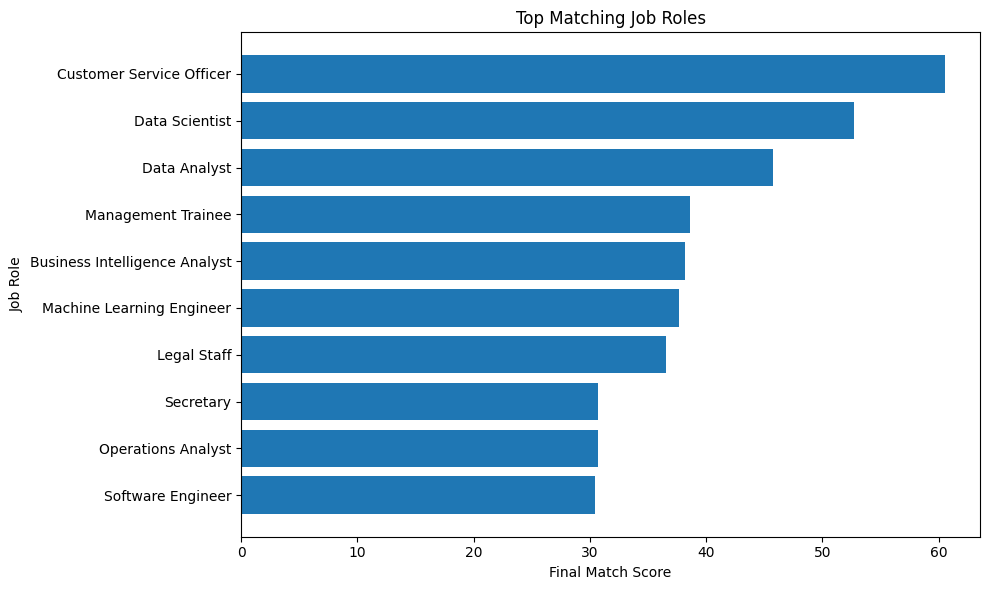

In [16]:
import matplotlib.pyplot as plt

plot_df = top_roles.sort_values("match_score", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["role"], plot_df["match_score"])
plt.xlabel("Final Match Score")
plt.ylabel("Job Role")
plt.title("Top Matching Job Roles")
plt.tight_layout()
plt.show()

In [17]:
category_summary = result_df.groupby("source_file", as_index=False).agg({
    "match_score": "mean",
    "skill_match_rate": "mean",
    "text_similarity": "mean"
})

category_summary

,source_file,match_score,skill_match_rate,text_similarity
0,it_jobs.txt,22.475,35.942143,2.276429
1,non_it_jobs.txt,22.081,36.042000,1.141500


In [18]:
OUTPUT_DIR = BASE_DIR / "report"
OUTPUT_DIR.mkdir(exist_ok=True)

result_df_export = result_df.copy()

result_df_export["matched_skills"] = result_df_export["matched_skills"].apply(lambda x: ", ".join(x))
result_df_export["missing_skills"] = result_df_export["missing_skills"].apply(lambda x: ", ".join(x))

result_df_export.to_csv(OUTPUT_DIR / "resume_job_match_result.csv", index=False)

print("Output saved to:", OUTPUT_DIR / "resume_job_match_result.csv")

Output saved to: ..\report\resume_job_match_result.csv
